# Phase Transition Discovery in the 2D Ising Model via Unsupervised ML
This notebook simulates the 2D Ferromagnetic Ising Model using a Metropolis-Hastings MCMC algorithm. It then applies Principal Component Analysis (PCA) and K-Means clustering to autonomously discover the phase transition and recover the physical order parameter.

## 1. The Physics Engine
Defining the system constraints and the Metropolis-Hastings algorithm to simulate thermal equilibrium.

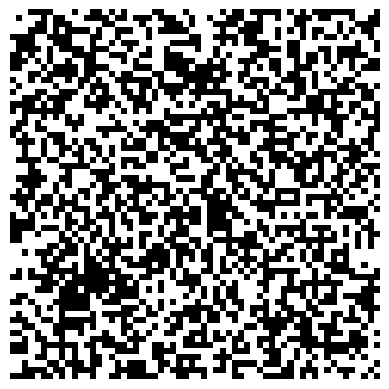

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def initialize_lattice(N):
    """Creates a grid of random +1 and -1 magnets."""
    return np.random.choice([-1,1], size=(N,N))
grid = initialize_lattice(60)
plt.imshow(grid, cmap='bone')
plt.axis('off')
plt.show()

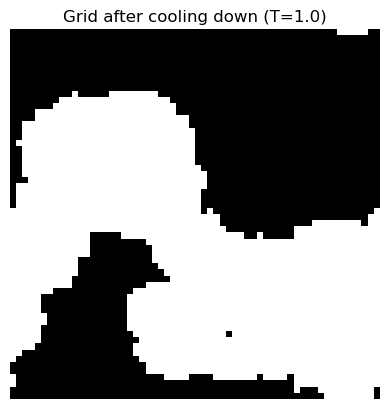

In [8]:
def metropolis_step(lattice, T):
    """Simulates the physics: magnets try to align, but the heat (T) jiggles them."""
    N = lattice.shape[0]
    for _ in range(N*N):
        i = np.random.randint(0, N)
        j = np.random.randint(0, N)
        s = lattice[i, j]

        neighbors = lattice[(i+1)%N, j] + lattice[(i-1)%N, j] + \
                    lattice[i, (j+1)%N] + lattice[i, (j-1)%N]
    
        dE = 2 * s * neighbors

        if dE < 0 or np.random.rand() < np.exp(-dE/T):
            lattice[i, j] *= -1
    return lattice

T_cold = 1.0
for step in range(100):
    grid = metropolis_step(grid, T_cold)

plt.imshow(grid, cmap='bone')
plt.axis('off')
plt.title("Grid after cooling down (T=1.0)")
plt.show()





## 2. Generating the Thermodynamic Dataset
Simulating the lattice across a temperature sweep from T=1.0 (Cold/Ordered) to T=4.0 (Hot/Disordered) to create the state vectors for the ML pipeline.

In [ ]:
import numpy as np

# In the Ising model, 'T' is a dimensionless number, not Celsius or Kelvin.
# It represents the ratio of Thermal Energy (shaking) to Magnetic Energy (glue).
# T = 1.0 (Cold): Magnetic glue wins. Spins align into solid black/white domains.
# T = 4.0 (Hot): Thermal shaking wins. Spins randomize into chaotic static.
# The critical "melting" point where the transition happens is exactly T_c = 2.269.
temperatures = np.linspace(1.0, 4.0, 50)

X_data = [] #flatenned grid
y_data = [] #temperature

for T in temperatures:
    grid = initialize_lattice(60)
    for _ in range(500):
        grid = metropolis_step(grid, T)

    X_data.append(grid.flatten())
    y_data.append(T)

X_data = np.array(X_data)
y_data = np.array(y_data)

print("Dataset complete!")
print("Shape of our image data (X):", X_data.shape)

## 3. Unsupervised ML: Dimensionality Reduction
Using PCA to compress the high-dimensional spin configurations into a 2D latent space, searching for spontaneous symmetry breaking.

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_data)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(X_pca[:,0], X_pca[:, 1], c=y_data, cmap='coolwarm', edgecolors='k')
plt.colorbar(scatter, label='Temperature Ratio (T)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('AI Discovery: PCA Projection of Ising Phases')
plt.grid(alpha=0.3)
plt.show()

## 4. Phase Classification
Applying K-Means to partition the PCA latent space into distinct physical phases without temperature labels.

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', edgecolors='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Unsupervised Phase Detection (K-Means)')
plt.show()

print("The AI has successfully partitioned your data into 3 distinct physical phases!")


## 5. Physical Validation and Observables
Comparing the AI-derived latent variables against classical statistical mechanics (Magnetization and Magnetic Susceptibility) to prove the validity of the unsupervised discovery.

In [ ]:
# Calculate Magnetization: average of the absolute values of the spins
# We use absolute value because +1 (all white) and -1 (all black) are both "ordered"
magnetizations = [np.abs(np.mean(state)) for state in X_data]

# Calculate the Variance of Magnetization (related to Magnetic Susceptibility)
# This peaks at the phase transition point!

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot 1: Physics (Magnetization)
ax1.plot(temperatures, magnetizations, 'o-', color='tab:red', label='Magnetization (Physics)')
ax1.set_xlabel('Temperature (T)')
ax1.set_ylabel('Order Parameter', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

# Plot 2: AI (PCA Component 1)
# We normalize it to fit on the same scale as magnetization
pca_comp1 = np.abs(X_pca[:, 0])
pca_comp1_normalized = (pca_comp1 - pca_comp1.min()) / (pca_comp1.max() - pca_comp1.min())

ax2 = ax1.twinx()
ax2.plot(temperatures, pca_comp1_normalized, 's--', color='tab:blue', label='PCA PC1 (AI)')
ax2.set_ylabel('AI Latent Variable', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Observability: Physics Magnetization vs. AI Prediction')
ax1.axvline(x=2.269, color='k', linestyle='--', label='Theoretical Tc')
fig.tight_layout()
plt.show()

In [ ]:
# ENSEMBLE SIMULATION SETTINGS
N_optimized = 40          # Grid size
n_samples = 50           # Number of temperature dots
n_trials = 10            # Run 10 independent simulations for each T

# Generate temperature sweep
temperatures = np.linspace(1.0, 4.0, n_samples)

# We will store the average PC1 and average Mag for each T
ensemble_avg_PC1 = []
ensemble_avg_Mag = []

print(f"Running ensemble simulation ({n_trials} trials per temperature).")

for T in temperatures:
    
    # Store the results of all 10 trials for this T
    trial_PC1_values = []
    trial_Mag_values = []
    
    for trial in range(n_trials):
        grid = initialize_lattice(N_optimized)
        
        # 1. Warm-up (reach equilibrium)
        for _ in range(400): 
            grid = metropolis_step(grid, T)
            
        # 2. Take multiple frames to get a temporal average for this trial
        frames_for_pca = []
        frames_for_mag = []
        for _ in range(10): # 10 quick frames
            grid = metropolis_step(grid, T)
            # Calculate the frame's magnetization immediately
            mag_of_frame = np.mean(grid)
            frames_for_mag.append(mag_of_frame)
            frames_for_pca.append(grid.flatten())
        
        # Apply PCA to the 10 frames from this trial
        pca_temp = PCA(n_components=1)
        frames_pca_transformed = pca_temp.fit_transform(np.array(frames_for_pca))
        
        # Calculate the trial's final averages
        trial_PC1_values.append(np.abs(np.mean(frames_pca_transformed)))
        trial_Mag_values.append(np.abs(np.mean(frames_for_mag)))

    # Calculate the average of all 10 trials for this temperature
    avg_PC1 = np.mean(trial_PC1_values)
    avg_Mag = np.mean(trial_Mag_values)
    
    ensemble_avg_PC1.append(avg_PC1)
    ensemble_avg_Mag.append(avg_Mag)

# Convert final lists to smooth vectors for plotting
x_final_PC1 = np.array(ensemble_avg_PC1)
y_final_Mag = np.array(ensemble_avg_Mag)
x_final_PC1_normalized = x_final_PC1 / np.max(x_final_PC1)

print("Done")

In [ ]:
# Find a temperature closest to Tc (2.269)
tc_idx = np.abs(y_data - 2.269).argmin()

plt.imshow(X_data[tc_idx].reshape(60, 60), cmap='bone')
plt.title(f"Critical State at T ≈ {y_data[tc_idx]:.2f}")
plt.axis('off')
plt.show()

In [ ]:
N_sus = 30 # We use a 30x30 grid here to make it run fast
true_susceptibility = []

print("Calculating true thermodynamic fluctuations...")

for T in temperatures:
    grid = initialize_lattice(N_sus)
    
    # 1. Let the system reach equilibrium first (warm-up)
    for _ in range(200):
        grid = metropolis_step(grid, T)
        
    # 2. Now, take a "video" of the magnetization over time
    M_over_time = []
    for _ in range(100):
        grid = metropolis_step(grid, T)
        # Record the absolute average magnetization of this frame
        M_over_time.append(np.abs(np.mean(grid))) 
        
    # 3. Calculate true susceptibility using the physics formula
    # Variance of M over time * (Number of spins / Temperature)
    chi = (N_sus**2 / T) * np.var(M_over_time)
    true_susceptibility.append(chi)

# Plotting the corrected physics
plt.figure(figsize=(8, 5))
plt.plot(temperatures, true_susceptibility, 'o-', color='tab:purple', label='True Susceptibility')
plt.axvline(x=2.269, color='k', linestyle='--', label='Theoretical Tc (2.269)')
plt.title("Magnetic Susceptibility (Temporal Fluctuations)")
plt.xlabel("Temperature (T)")
plt.ylabel("Susceptibility $\chi$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(range(1, 3), pca.explained_variance_ratio_, alpha=0.7)
plt.xticks([1, 2], ['PC1', 'PC2'])
plt.ylabel('Explained Variance Ratio')
plt.title('How much info did PCA capture?')
plt.show()